Import packages

In [ ]:
from pathlib import Path
import re
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Make Folders for Data Files


Folder will have these following files:


1.   Protein Abundance Table (/content/Project_1_Data_File/pten-variant-abundance (5).csv)
2.   Complete Published Score Table - Raw File (/content/Project_1_Data_File/mavedb-00000013-a-1-scores (3).csv)
3.   PTEN Reference Protein Sequence (/content/Project_1_Data_File/pten-reference-protein (1).fasta)
4.   PTEN region annotations (/content/Project_1_Data_File/pten-region-annotations (3).csv)
5.   Small Preview Table (/content/Project_1_Data_File/pten-teaching-examples (1).csv)





In [ ]:
import os

os.makedirs("/content/Project_1_Data_File", exist_ok=True)

print("Project 1 Data File folder created!")

Project 1 Data File folder created!


Assignment

Total missense variants: 4112
Positions: 403
Mean variants per position: 10.2
Median: 12.0  Max: 19
Positions with no variants: 43
Positions with 1-4 variants: 43
Positions with 5+ variants: 317
Positions with no variants: [8, 32, 33, 34, 41, 42, 70, 99, 101, 113, 132, 150, 169, 173, 180, 181, 183, 185, 190, 198, 200, 221, 251, 267, 283, 290, 291, 301, 302, 317, 323, 324, 326, 327, 328, 350, 352, 353, 359, 373, 374, 381, 382]
          n_variants      mean   median       std       min       max
position                                                             
1                  1       NaN      NaN       NaN       NaN       NaN
2                  9  0.910278  0.87283  0.160115  0.666592  1.190667
3                  3       NaN      NaN       NaN       NaN       NaN
4                  4       NaN      NaN       NaN       NaN       NaN
5                  7  1.086673  1.17585  0.226878  0.647629  1.336240
Positions passing threshold: 317


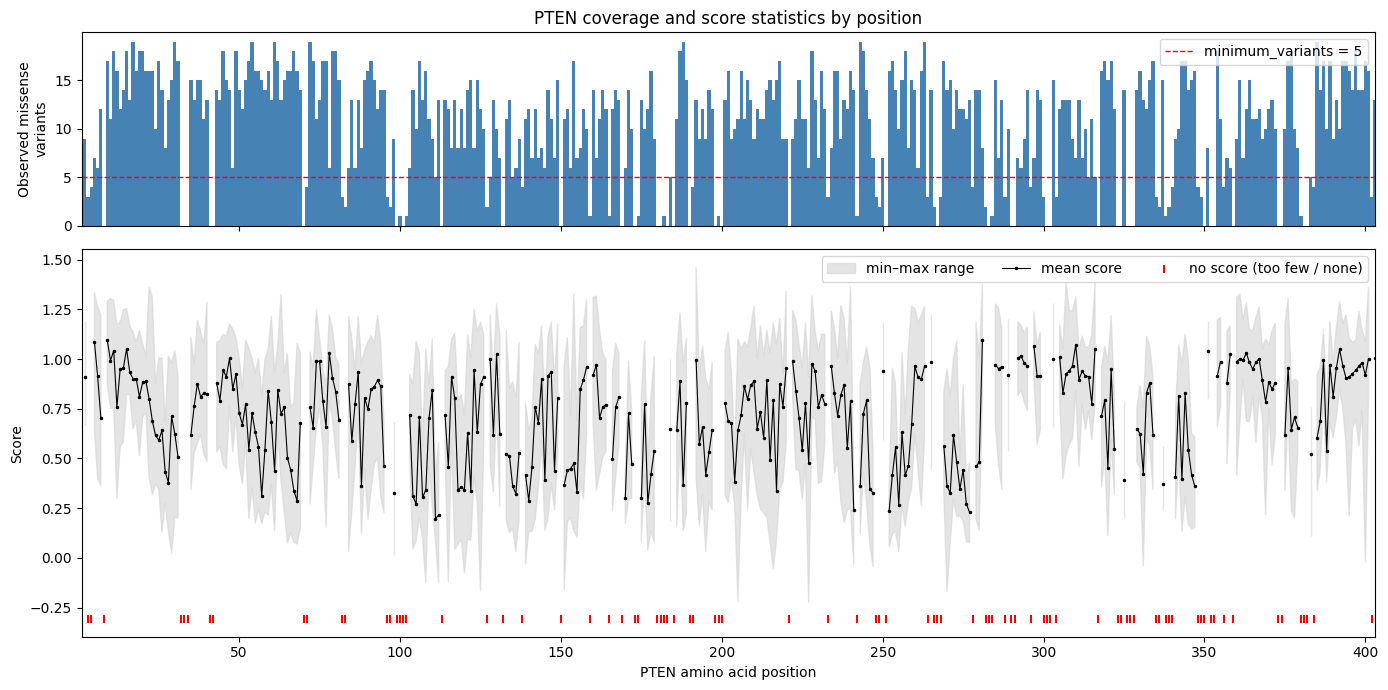

In [ ]:
##PTEN abundance analysis: coverage + per-position score statistics.


#import packages:
import numpy as np
import pandas as pd
import requests
import os

# Convert 3 letter amino acids to 1 letters the FASTA uses
# 1-letter codes (e.g. "H"). This table converts between them.
# "Ter" (stop codon) is deliberately NOT here, so nonsense variants get rejected.
AMINO_ACIDS = {"Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C",
    "Gln": "Q", "Glu": "E", "Gly": "G", "His": "H", "Ile": "I",
    "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F", "Pro": "P",
    "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",}

#Now look at the protein reference file
def read_fasta(file_path):
  #Return the protein sequence as one string:
    sequence = ""
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith(">"):   # skip blank lines and the ">" header
                sequence += line
    return sequence


#Split a missense variant name into (original, position, new) residues.
##hgvs -> this is a function; inside the function, there will be a value
def parse_missense(hgvs):

    text = str(hgvs)
    if not text.startswith("p."):
        raise ValueError(f"Not a missense variant: {hgvs!r}")

    body = text[2:]                # "His75Asp"
    original = body[:3]            # first 3 letters: "His"
    new = body[-3:]                # last 3 letters:  "Asp"
    position = body[3:-3]          # what is left:    "75"

    if original not in AMINO_ACIDS or new not in AMINO_ACIDS:
        raise ValueError(f"Not a missense variant: {hgvs!r}")
    if not position.isdigit():
        raise ValueError(f"Not a missense variant: {hgvs!r}")
    if original == new:
        raise ValueError(f"Original and new residue are the same: {hgvs!r}")

    return AMINO_ACIDS[original], int(position), AMINO_ACIDS[new]


#Return missense variants with WT/position/mut columns; raise on bad data
def load_missense(csv_path, seq):

    df = pd.read_csv(csv_path)
    df = df[df["record_type"] == "missense"].copy()
    df[["wt", "position", "mut"]] = [parse_missense(h) for h in df["hgvs_pro"]]
    if not df["position"].between(1, len(seq)).all():
        raise ValueError("Position outside protein")
    if any(seq[p - 1] != w for p, w in zip(df["position"], df["wt"])):
        raise ValueError("Wild-type residue does not match reference")
    if df["hgvs_pro"].duplicated().any():
        raise ValueError("Duplicate variants")
    return df.dropna(subset=["score"])      # missing scores are dropped, never 0


# Number of missense variants observed for each a.a. position for the entirety
# of the length of the protein; if no missense variants measured, system will
# return a 0
def coverage(df, length):
    return df.groupby("position").size().reindex(range(1, length + 1), fill_value=0)


#Mean, median, standard deviation per position; NaN if fewer than minimum_variants
def position_score_stats(df, position_col="position", score_col="score",
                         minimum_variants=5, n_positions=403):
    """
    Per-position score statistics, only for positions with at least
    `minimum_variants` included (non-missing) substitutions.
    Positions that don't qualify get NaN, never 0.
    """
# 1. Keep only substitutions that count: missense with a real score.
# Filter out synonymous/nonsense/etc. before this if they're in your table.)
    included = df.dropna(subset=[score_col])

# 2. Aggregate per position
    stats = (
        included.groupby(position_col)[score_col]
        .agg(n_variants="count", mean="mean", median="median",
             std="std", min="min", max="max")
    )

# 3. Mask stats where there are too few substitutions
    too_few = stats["n_variants"] < minimum_variants
    stat_cols = ["mean", "median", "std", "min", "max"]
    stats.loc[too_few, stat_cols] = np.nan

# 4. Reindex to ALL positions so unmeasured ones appear as NaN, not missing rows
    stats = stats.reindex(range(1, n_positions + 1))
    stats["n_variants"] = stats["n_variants"].fillna(0).astype(int)
    stats.index.name = position_col

    return stats

DATA = "/content/Project_1_Data_File"
seq = read_fasta(DATA + "/pten-reference-protein (1).fasta")
df = load_missense(DATA + "/pten-variant-abundance (5).csv", seq)

cov = coverage(df=df, length=len(seq))

print("Total missense variants:", cov.sum())
print("Positions:", len(cov))
print("Mean variants per position:", round(cov.mean(), 1))
print("Median:", cov.median(), " Max:", cov.max())
print("Positions with no variants:", (cov == 0).sum())
print("Positions with 1-4 variants:", ((cov >= 1) & (cov < 5)).sum())
print("Positions with 5+ variants:", (cov >= 5).sum())
print("Positions with no variants:", list(cov[cov == 0].index))


pos_stats = position_score_stats(df, minimum_variants=5)
print(pos_stats.head())
print("Positions passing threshold:", pos_stats["mean"].notna().sum())


import matplotlib.pyplot as plt

def plot_pten_summary(cov, pos_stats, minimum_variants=5, n_positions=403):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                   gridspec_kw={"height_ratios": [1, 2]})

# Top: coverage (observed missense variants per position)
    ax1.bar(cov.index, cov.values, width=1.0, color="steelblue")
    ax1.axhline(minimum_variants, color="red", ls="--", lw=1,
                label=f"minimum_variants = {minimum_variants}")
    ax1.set_ylabel("Observed missense\nvariants")
    ax1.set_title("PTEN coverage and score statistics by position")
    ax1.legend(loc="upper right")

# Bottom: mean score with min/max range; NaN shows as gaps
    x = pos_stats.index
    ax2.fill_between(x, pos_stats["min"], pos_stats["max"],
                     color="lightgray", alpha=0.6, label="min–max range")
    ax2.plot(x, pos_stats["mean"], marker=".", ms=3, lw=0.8,
             color="black", label="mean score")

# Mark positions with no usable statistic so gaps are visibly "missing"
    missing = pos_stats["mean"].isna()
    ymin = ax2.get_ylim()[0]
    ax2.scatter(x[missing], [ymin] * missing.sum(), marker="|",
                color="red", s=30, label="no score (too few / none)")

    ax2.set_xlabel("PTEN amino acid position")
    ax2.set_ylabel("Score")
    ax2.set_xlim(1, n_positions)
    ax2.legend(loc="upper right", ncol=3)

    plt.tight_layout()
    return fig

cov = coverage(df, length=len(seq)) # Corrected function call and arguments
pos_stats = position_score_stats(df, minimum_variants=5)
fig = plot_pten_summary(cov, pos_stats)
fig.savefig("pten_coverage_scores.png", dpi=200)
plt.show()
